# RNE Energy-based Training

This notebook is a tutorial of RNE for diffusion energy-based training.
We will show how to learn an energy-based diffusion model for Gaussian Mixture Model using RNE regularization.



## Prepare

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import OrderedDict

In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import itertools


class GMM(torch.nn.Module):
    def __init__(self, dim, n_mixes, loc_scaling, log_var_scaling=0.1, mean_shift=0,  seed=0,
                 n_test_set_samples=1000, device="cpu"):
        super(GMM, self).__init__()
        torch.manual_seed(seed)

        self.seed = seed
        self.n_mixes = n_mixes
        self.dim = dim
        self.n_test_set_samples = n_test_set_samples

        mean = (torch.rand((n_mixes, dim)) - 0.5)*2 * loc_scaling + mean_shift
        log_var = torch.ones((n_mixes, dim)) * log_var_scaling

        self.register_buffer("cat_probs", torch.ones(n_mixes))
        self.register_buffer("locs", mean)
        self.register_buffer("scale_trils", torch.diag_embed(torch.nn.functional.softplus(log_var)))
        self.device = device
        self.to(self.device)

        self.call_time = 0

    def to(self, device):
        if device == "cuda":
            if torch.cuda.is_available():
                self.cuda()
        else:
            self.cpu()

    @property
    def distribution(self):
        mix = torch.distributions.Categorical(self.cat_probs.to(self.device))
        com = torch.distributions.MultivariateNormal(self.locs.to(self.device),
                                                     scale_tril=self.scale_trils.to(self.device),
                                                     validate_args=False)
        return torch.distributions.MixtureSameFamily(mixture_distribution=mix,
                                                     component_distribution=com,
                                                     validate_args=False)

    @property
    def test_set(self) -> torch.Tensor:
        return self.sample((self.n_test_set_samples, ))

    def log_prob(self, x: torch.Tensor, count_call=True):
        log_prob = self.distribution.log_prob(x)
        mask = torch.zeros_like(log_prob)
        mask[log_prob < -1e4] = - torch.tensor(float("inf"))
        log_prob = log_prob + mask
        if count_call:
            self.call_time += x.shape[0]
        return log_prob

    def score(self, x: torch.Tensor, count_call=True):
        with torch.enable_grad():
            x.requires_grad = True
            logp = self.log_prob(x, count_call)
            score = torch.autograd.grad(logp.sum(), x)[0]
        return score 

    def sample(self, shape=(1,), count_call=True):
        if count_call:
            self.call_time += shape[0]
        return self.distribution.sample(shape)
    
    def get_sample_and_logp(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        logp = self.log_prob(samples, count_call)
        return samples, logp
    
    def get_sample_and_score(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        with torch.enable_grad():
            samples.requires_grad = True
            logp = self.log_prob(samples, count_call)
            score = torch.autograd.grad(logp.sum(), samples)[0]
        return samples.detach(), score

def plot_contours(log_prob_func,
                  samples = None,
                  ax = None,
                  bounds = (-5.0, 5.0),
                  grid_width_n_points = 20,
                  n_contour_levels = None,
                  log_prob_min = -1000.0,
                  device='cpu',
                  plot_marginal_dims=[0, 1],
                  s=2,
                  alpha=0.6,
                  title=None,
                  plt_show=True,
                  xy_tick=True,):
    """Plot contours of a log_prob_func that is defined on 2D"""
    if ax is None:
        fig, ax = plt.subplots(1)
    x_points_dim1 = torch.linspace(bounds[0], bounds[1], grid_width_n_points)
    x_points_dim2 = x_points_dim1
    x_points = torch.tensor(list(itertools.product(x_points_dim1, x_points_dim2)), device=device)
    log_p_x = log_prob_func(x_points).cpu().detach()
    log_p_x = torch.clamp_min(log_p_x, log_prob_min)
    log_p_x = log_p_x.reshape((grid_width_n_points, grid_width_n_points))
    x_points_dim1 = x_points[:, 0].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    x_points_dim2 = x_points[:, 1].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    if n_contour_levels:
        ax.contour(x_points_dim1, x_points_dim2, log_p_x, levels=n_contour_levels)
    else:
        ax.contour(x_points_dim1, x_points_dim2, log_p_x)

    if samples is not None:
        samples = np.clip(samples.detach().cpu(), bounds[0], bounds[1])
        ax.scatter(samples[:, plot_marginal_dims[0]], samples[:, plot_marginal_dims[1]], s=s, alpha=alpha)
        ### x,y ticks
        if xy_tick:
            ax.set_xticks([-40,0,40])
            ax.set_yticks([-40,0,40])
        ### size of ticks
        ax.tick_params(axis='both', which='major', labelsize=15)
    if title:
        ax.set_title(title)
        ### size of title 
        ax.title.set_fontsize(40)
    if plt_show:
        plt.show()




def plot_contours(log_prob_func,
                  bounds = (-2.0, 2.0),
                  grid_width_n_points = 20,
                  n_contour_levels = None,
                  log_prob_min = -1000.0,
                  device='cpu',
                  plot_marginal_dims=[0, 1],
                  alpha=0.6,):
    x_points_dim1 = torch.linspace(bounds[0], bounds[1], grid_width_n_points)
    x_points_dim2 = x_points_dim1
    x_points = torch.tensor(list(itertools.product(x_points_dim1, x_points_dim2)), device=device)
    log_p_x = log_prob_func(x_points).cpu().detach()
    log_p_x = torch.clamp_min(log_p_x, log_prob_min)
    log_p_x = log_p_x.reshape((grid_width_n_points, grid_width_n_points))
    x_points_dim1 = x_points[:, 0].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    x_points_dim2 = x_points[:, 1].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    if n_contour_levels:
        plt.contour(x_points_dim1, x_points_dim2, log_p_x, levels=n_contour_levels)
    else:
        plt.contour(x_points_dim1, x_points_dim2, log_p_x)




class GMM_t(torch.nn.Module):
    def __init__(self, t, mean, dim, n_mixes, loc_scaling, log_var_scaling=0.1, mean_shift=0,  seed=0,
                 n_test_set_samples=1000, device="cpu"):
        super(GMM_t, self).__init__()

        self.seed = seed
        self.n_mixes = n_mixes
        self.dim = dim
        self.n_test_set_samples = n_test_set_samples

        mean = mean
        log_var = (torch.ones((n_mixes, dim)) * log_var_scaling).to(device)

        self.register_buffer("cat_probs1", torch.ones(n_mixes))
        self.register_buffer("locs1", mean)
        self.register_buffer("scale_trils1", torch.diag_embed((torch.nn.functional.softplus(log_var)**2 + t**2) ** 0.5))
        self.device = device
        self.to(self.device)

        self.call_time = 0

    def to(self, device):
        if device == "cuda":
            if torch.cuda.is_available():
                self.cuda()
        else:
            self.cpu()
        return self

    @property
    def distribution(self):
        mix = torch.distributions.Categorical(self.cat_probs1.to(self.device))
        com = torch.distributions.MultivariateNormal(self.locs1.to(self.device),
                                                     scale_tril=self.scale_trils1.to(self.device),
                                                     validate_args=False)
        return torch.distributions.MixtureSameFamily(mixture_distribution=mix,
                                                     component_distribution=com,
                                                     validate_args=False)

    @property
    def test_set(self) -> torch.Tensor:
        return self.sample((self.n_test_set_samples, ))

    def log_prob(self, x: torch.Tensor, count_call=True):
        log_prob = self.distribution.log_prob(x)
        log_prob = log_prob
        if count_call:
            self.call_time += x.shape[0]
        return log_prob

    def score(self, x: torch.Tensor, count_call=True):
        with torch.enable_grad():
            x.requires_grad = True
            logp = self.log_prob(x, count_call)
            score = torch.autograd.grad(logp.sum(), x)[0]
        return score 

    def sample(self, shape=(1,), count_call=True):
        if count_call:
            self.call_time += shape[0]
        return self.distribution.sample(shape)
    
    def get_sample_and_logp(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        logp = self.log_prob(samples, count_call)
        return samples, logp
    
    def get_sample_and_score(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        with torch.enable_grad():
            samples.requires_grad = True
            logp = self.log_prob(samples, count_call)
            score = torch.autograd.grad(logp.sum(), samples)[0]
        return samples.detach(), score

In [3]:
dim = 2
n_mix = 40
loc_scale = 1.0
log_var = -3.

gmm = GMM(dim, n_mix, loc_scale, log_var)

In [4]:
device = 'cpu'

### Define Model

Here the model is an energy-based model, the output is a scalar and score will be obtained by taking gradient.

In [5]:
from torch import nn
import torch
import numpy as np


class PositionalEmbedding(torch.nn.Module):
    def __init__(self, num_channels, max_positions=10000, endpoint=False):
        super().__init__()
        self.num_channels = num_channels
        self.max_positions = max_positions
        self.endpoint = endpoint

    def forward(self, x):
        x = (x + 1e-1).log() / 4
        freqs = torch.arange(start=0, end=self.num_channels//2, dtype=torch.float32, device=x.device)
        freqs = freqs / (self.num_channels // 2 - (1 if self.endpoint else 0))
        freqs = (1 / self.max_positions) ** freqs
        x = x.ger(freqs.to(x.dtype))
        x = torch.cat([x.cos(), x.sin()], dim=1)
        return x
    
class MLP(nn.Module):
    
    def __init__(self, 
                 dim, 
                 device,
                 data_sigma: float = 1.0,
                 num_layers: int = 4,
                 num_hid: int = 256,
                 clip: float = 1e4,
                 *args, **kwargs):
        super().__init__()
        self.dim = dim
        self.num_layers = num_layers
        self.num_hid = num_hid
        self.clip = clip


        self.time_embed = PositionalEmbedding(self.num_hid)

        self.time_coder_state = nn.Sequential(*[
            nn.Linear(self.num_hid, self.num_hid),
            nn.GELU(),
            nn.Linear(self.num_hid, self.num_hid),
        ])
        self.state_time_net = [nn.Sequential(
            *[nn.Linear(self.num_hid+self.dim, self.num_hid), nn.GELU()])] + [nn.Sequential(
            *[nn.Linear(self.num_hid, self.num_hid), nn.GELU()]) for _ in range(self.num_layers-1)] + [
                                                nn.Linear(self.num_hid, self.dim)]
        self.state_time_net = nn.Sequential(*self.state_time_net)
        self.data_sigma = data_sigma

    def _forward(self, input_array, time_array, *args, **kwargs):
        time_array_emb = self.time_embed(time_array)
        t_net1 = self.time_coder_state(time_array_emb)

        extended_input = torch.cat((input_array, t_net1), -1)
        out_state = self.state_time_net(extended_input)
        return out_state
    
    def logp(self, input_array, time_array, *args, **kwargs):
        c_in = 1 / (self.data_sigma**2 + time_array[:, None]**2)**0.5
        out = self._forward(input_array * c_in, time_array, *args, **kwargs)
        # c_skip = self.data_sigma**2 / (self.data_sigma**2 + time_array[:, None]**2)
        # c_out = self.data_sigma*time_array[:, None] / (self.data_sigma**2 + time_array[:, None]**2)**0.5
        # return input_array * c_skip + out * c_out
        return (out * input_array).sum(dim=-1, keepdim=True)
    
    def forward(self, input_array, time_array, *args, **kwargs):
        with torch.enable_grad():
            input_array = input_array.requires_grad_(True)
            logp = self.logp(input_array, time_array, *args, **kwargs)
            score = torch.autograd.grad(logp.sum(), input_array, create_graph=True)[0]
            return score

In [6]:
def log_norm_prob(x, mu, std):
    # expand std to match x shape
    std = std.expand(x.shape)
    return -0.5 * ((x - mu) / std).pow(2).sum(-1) - (std.log() + np.log(2*np.pi)/2).sum(-1)

In [7]:


def update_sg_model(mu, online_model, sg_model):
    with torch.no_grad():
        online_params = OrderedDict(online_model.named_parameters())
        sg_params = OrderedDict(sg_model.named_parameters())

        # check if both model contains the same set of keys
        assert online_params.keys() == sg_params.keys()

        for name, param in online_params.items():
            # see https://www.tensorflow.org/api_docs/python/tf/train/ExponentialMovingAverage
            # shadow_variable -= (1 - decay) * (shadow_variable - variable)
            sg_params[name].sub_((1. - mu) * (sg_params[name] - param))
            sg_params[name].require_grad = False

        online_buffers = OrderedDict(online_model.named_buffers())
        sg_buffers = OrderedDict(sg_model.named_buffers())

        # check if both model contains the same set of keys
        assert online_buffers.keys() == sg_buffers.keys()

        for name, buffer in online_buffers.items():
            # buffers are copied
            sg_buffers[name].copy_(buffer)

### DSM LOSS

In [8]:
def DSM_loss(x_t, models, x0, t):

    score = models(x_t, t)
    x_hat = score * t[:, None]**2 + x_t
    dsm_loss = (((x0 - x_hat)**2).sum(-1) / t**2).mean()
    return dsm_loss


### RNE Regularization


Here we will define the loss to regularize the energy based network with RNE estimator.

#### Intuitive Explanation of RNE



RNE is based on the following observation:

> For a well trained diffusion model, the forward process (noising process) and the backward process (denoising process) defines the same probabilty distribution.

The forward process from $t_n$ to $t_m$ is: $$p_n(x_n)p(x_{n+1}|x_n) \cdots p(x_{m}|x_{m-1})$$
The transiton kernels $p(x_{n+1}|x_n) \cdots p(x_{m}|x_{m-1})$ are simply Gaussian noising kernels.

The backward process from $t_m$ is: $$p_m(x_m)p(x_{m-1}|x_m) \cdots p(x_{n}|x_{n+1})$$
The transiton kernels $p_m(x_m)p(x_{m-1}|x_m) \cdots p(x_{n}|x_{n+1})$ are also simply Gaussian denoising kernels (with the learned score network).

Therefore, 
\begin{align*}
p_n(x_n)
p(x_{n+1}|x_n) \cdots p(x_{m}|x_{m-1})  =  p_m(x_m)p(x_{m-1}|x_m) \cdots p(x_{n}|x_{n+1})
\end{align*}


This is an intuitive explanation to the RNE in discrete time. In continuous-time limit, we also provide its form in the paper. 

For simplicity, we will only consider 1 step in the following. That is:
\begin{align}
p_n(x_n) / p_{n+1}(x_{n+1})
 =  p(x_{n}|x_{n+1}) / p(x_{n+1}|x_n) 
\tag{*}
\end{align}



#### RNE with Analytical Reference

In our paper, we introduce an analytical reference to reduce the error of RNE.

An intuitive motivation for the reference is as follows. The discretisation error for forward process and backward process is different. Even the estimator is valid in continuous time, it does not mean there is numerical-error free in discrete time. To reduce the error, a better way is to introduce a pair of forward-forward process (or backward-backward), instead of a forward-backward pair.

Luckily, for the diffusion model we typically choose, if we start from a Gaussian distribution, then we know everything for the process: the marginal, the score, the transition kernel, etc. Therefore, we can directly write down its forward and backward process:

\begin{align}
 &\pi_n(x_n)\pi(x_{n+1}|x_n) \\ &= \\ &\pi_{n+1}(x_{n+1})\pi(x_{n}|x_{n+1}) 
\end{align}


For example, in our example in this notebook, we start from a Gaussian $\pi_0=\mathcal{N}(0, I)$, and the noising process follows EDM. Therefore, $\pi_t=\mathcal{N}(0, (1+t^2)I)$. Using this we can calculate the forward and backward transition kernel. In the code, this is done by 

```python
# analytical marginal std and score
ref_std = lambda time: (1**2 + time ** 2)**0.5
ref_score = lambda x, time: - x / ref_std(time) ** 2

# ref forward process
fwd_mean = samples_new
fwd_std = torch.sqrt(2*Delta_t*t_1)
ref_fwd = log_norm_prob(samples_new, 0, ref_std(t_1)) # marginal density at t_1
ref_fwd += log_norm_prob(samples, fwd_mean, fwd_std) # transition kernel density from t to t_1

# ref backward process
bwd_mean = samples + ref_score(samples, t) * 2 * t * Delta_t
bwd_std = torch.sqrt(2*Delta_t*t)
ref_bwd = log_norm_prob(samples, 0, ref_std(t)) # marginal density at t
ref_bwd += log_norm_prob(samples_new, bwd_mean, bwd_std) # transition kernel density from t_1 to t

```


From equation (1)-(3), we know in the ideal case, (1) should be the same  as (3). Therefore, we can freely insert (1)/(3) to our previous estimator (*).


This gives us a more stable and more accurate estimator:


\begin{align}
\frac{ p_{n+1}(x_{n+1}) }{p_n(x_n)}\frac{p(x_{n}|x_{n+1}) }{ p(x_{n+1}|x_n) } \frac{  \pi_n(x_n)\pi(x_{n+1}|x_n) }{ \pi_{n+1}(x_{n+1})\pi(x_{n}|x_{n+1}) } = 1\tag{**}
\end{align}






#### Regularization with RNE

Inspired by (**), we can train energy-based DM with RNE regularization:

\begin{align}
|\log \frac{ p_{n+1}(x_{n+1}) }{p_n(x_n)}\frac{p(x_{n}|x_{n+1}) }{ p(x_{n+1}|x_n) } \frac{  \pi_n(x_n)\pi(x_{n+1}|x_n) }{ \pi_{n+1}(x_{n+1})\pi(x_{n}|x_{n+1}) } |^2 tag{***}
\end{align}

In practice, we stop the gradient for transiton kernels and only keep gradient on the marginal density to be learned.

In [9]:
def rne_loss(x_t, models, t, Delta_t):
    t_1 = t + Delta_t
    t = t.reshape(-1, 1)
    t_1 = t_1.reshape(-1, 1)
    # diffusion forward process
    fwd_mean = x_t
    fwd_std = torch.sqrt(2*Delta_t*t)
    x_t1 = x_t + fwd_std * torch.randn_like(x_t)

    x_t1 = x_t1.detach()
    x_t = x_t.detach()

    dm_fwd = log_norm_prob(x_t1, fwd_mean, fwd_std)

    # diffusion backward process
    score = models.forward(x_t1, t_1.squeeze())
    bwd_mean = x_t1 + score * 2 * t_1 * Delta_t
    bwd_std = torch.sqrt(2*Delta_t*t_1)
    dm_bwd = log_norm_prob(x_t, bwd_mean, bwd_std)

    # define reference distribution
    ref_std = lambda time: (1**2 + time ** 2)**0.5
    ref_score = lambda x, time: - x / ref_std(time) ** 2
    # ref forward process: p(x_t) p(x_t1|x_t)
    fwd_mean = x_t
    fwd_std = torch.sqrt(2*Delta_t*t)
    ref_fwd = log_norm_prob(x_t, 0, ref_std(t)) + log_norm_prob(x_t1, fwd_mean, fwd_std)

    # ref backward process: p(x_t1) p(x_t|x_t1)
    bwd_mean = x_t1 + ref_score(x_t1, t_1) * 2 * t_1 * Delta_t
    bwd_std = torch.sqrt(2*Delta_t*t_1)
    ref_bwd = log_norm_prob(x_t1, 0, ref_std(t_1)) + log_norm_prob(x_t, bwd_mean, bwd_std)


    pt = models.logp(x_t, t.squeeze()).flatten()
    pt1 = models.logp(x_t1, t_1.squeeze()).flatten()

    R = (pt + dm_fwd.detach() - dm_bwd.detach() - ref_fwd.detach() + ref_bwd.detach() - pt1)**2
    return R.mean()

## Train energy-based DM with RNE

In [10]:
from copy import deepcopy

denoising_net = MLP(dim, device, gmm.sample([1000]).std().item()).to(device)
opt = torch.optim.Adam(denoising_net.parameters(), lr=1e-4)

ema_decay = 0.99
ema_net = deepcopy(denoising_net).to(device)

In [11]:
n_epoch = 100000
batch_size = 1024

In [12]:
LOSS = []
for epoch in tqdm(range(n_epoch)):

    x = gmm.sample([batch_size]).to(device)

    logt = torch.randn(batch_size).to(device) * 1.2 - 1.2
    noises = torch.randn_like(x)
    x_t = x + noises * logt.exp()[:, None]

    loss = DSM_loss(x_t, denoising_net, x, logt.exp()) + 1e3 * rne_loss(x_t, denoising_net, logt.exp(), 0.0001)
    if epoch % 1000 ==0:
        print("rne_loss: ", rne_loss(x_t, denoising_net, logt.exp(), 0.001).item())
    loss.backward()
    opt.step()
    opt.zero_grad()
    LOSS.append(loss.item())

    update_sg_model(ema_decay, denoising_net, ema_net)



  0%|          | 9/100000 [00:00<40:26, 41.21it/s]

rne_loss:  4.5775564672112523e-07


  1%|          | 1009/100000 [00:22<36:29, 45.21it/s]

rne_loss:  3.282358193246182e-06


  2%|▏         | 2009/100000 [00:44<36:27, 44.79it/s]

...

 98%|█████████▊| 98005/100000 [1:49:22<00:50, 39.40it/s]

rne_loss:  5.963610237813555e-05


 99%|█████████▉| 99005/100000 [2:08:27<00:28, 34.77it/s]     

rne_loss:  7.040345371933654e-05


100%|██████████| 100000/100000 [2:08:53<00:00, 12.93it/s]


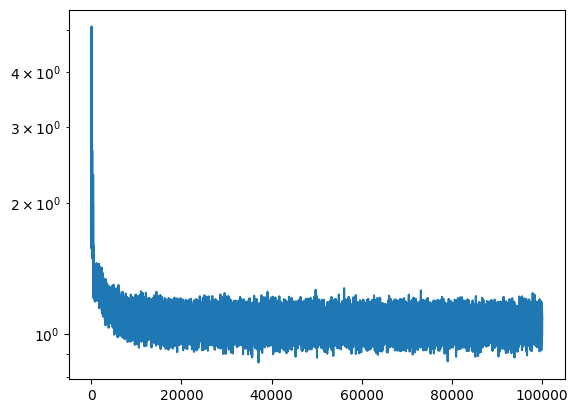

In [13]:

plt.plot(LOSS)
plt.yscale('log')


In [14]:
# save the model
torch.save(ema_net.state_dict(), 'denoising_net2.pth')

In [15]:
# # # load the model
# ema_net.load_state_dict(torch.load('denoising_net.pth'))

In [16]:
t = 0.

In [17]:
tmax = 10
tmin = 1e-3
rho = 7
steps = 500

ts = tmin ** (1/rho) + np.arange(steps)/(steps-1) * (tmax ** (1/rho) - tmin ** (1/rho))
ts = ts ** rho
R2 = []
for t in ts:
    with torch.no_grad():
        x = gmm.sample([1000]).to(device)
        pred = ema_net.logp(x, torch.zeros(1000).to(device)+t).cpu().numpy().flatten()
    gmm_t = GMM_t(t, gmm.locs, dim, n_mix, loc_scale, log_var_scaling=log_var, device=device)
    gt = gmm_t.log_prob(x).cpu().numpy().flatten()
    # calculate R2 score with scipy
    from scipy.stats import linregress
    slope, intercept, r_value, p_value, std_err = linregress(gt, pred)
    R2.append(r_value ** 2)




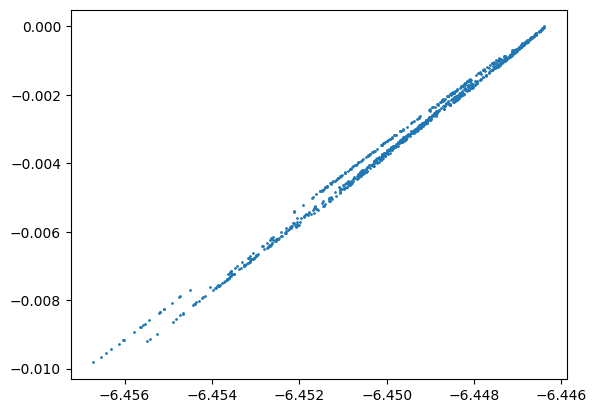

In [18]:
plt.scatter(gt, pred, s=1)

In [19]:
from matplotlib.colors import LinearSegmentedColormap, ColorConverter
from matplotlib import patches as mpatches
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
__all__ = ["paletteFessa", "paletteCortina","plot_metrics","plot_features_distribution"]

# Fessa colormap
paletteFessa = [
    "#1F3B73",  # dark-blue
    "#2F9294",  # green-blue
    "#50B28D",  # green
    "#A7D655",  # pisello
    "#FFE03E",  # yellow
    "#FFA955",  # orange
    "#D6573B",  # red
]

cm_fessa = LinearSegmentedColormap.from_list("fessa", paletteFessa)
mpl.colormaps.register(cmap=cm_fessa)
mpl.colormaps.register(cmap=cm_fessa.reversed())

for i in range(len(paletteFessa)):
    ColorConverter.colors[f"fessa{i}"] = paletteFessa[i]

# Cortina1980 colormap
paletteCortina = [
    [0.0, 0.0, 0.803921568627451, 1],  # mediumblue
    [0.4823529411764706, 0.40784313725490196, 0.9333333333333333, 1],  # mediumslateblue
    [0.0, 0.9803921568627451, 0.6039215686274509, 1],  # mediumspringgreen
    [0.23529411764705882, 0.7019607843137254, 0.44313725490196076, 1],  # mediumseagreen
    [0.8588235294117647, 0.4392156862745098, 0.5764705882352941, 1],  # palevioletred
    [0.7803921568627451, 0.08235294117647059, 0.5215686274509804, 1],  # mediumvioletred
]

cm_cortina = LinearSegmentedColormap.from_list("cortina80", paletteCortina)
mpl.colormaps.register(cmap=cm_cortina)
mpl.colormaps.register(cmap=cm_cortina.reversed())

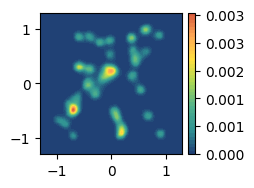

In [20]:
# contour plot
plt.figure(figsize=(2, 2))
# ensure the plot is square
plt.gca().set_aspect('equal', adjustable='box')
x1 = np.linspace(-1.3, 1.3, 100)
x2 = np.linspace(-1.3, 1.3, 100)
X1, X2 = np.meshgrid(x1, x2)
X = np.stack([X1.flatten(), X2.flatten()], axis=-1)
X = torch.tensor(X, dtype=torch.float32).to(device)
with torch.no_grad():
    logp = ema_net.logp(X, torch.zeros(X.shape[0]).to(device))
    Z = logp.exp().cpu().numpy() / logp.exp().sum().cpu().numpy()
Z = Z.reshape(X1.shape)
plt.contourf(X1, X2, Z, levels=50, cmap="fessa")
# make the colorbar size smaller
plt.colorbar(fraction=0.0456, pad=0.04, format='%.3f', ticks=np.linspace(Z.min(), Z.max(), 6))



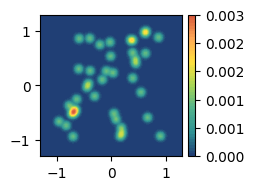

In [21]:
# contour plot
plt.figure(figsize=(2, 2))
# ensure the plot is square
plt.gca().set_aspect('equal', adjustable='box')
x1 = np.linspace(-1.3, 1.3, 100)
x2 = np.linspace(-1.3, 1.3, 100)
X1, X2 = np.meshgrid(x1, x2)
X = np.stack([X1.flatten(), X2.flatten()], axis=-1)
X = torch.tensor(X, dtype=torch.float32).to(device)
with torch.no_grad():
    logp = gmm.log_prob(X.cpu())
    Z = logp.exp().cpu().numpy() / logp.exp().sum().cpu().numpy()
Z = Z.reshape(X1.shape)
plt.contourf(X1, X2, Z, levels=50, cmap="fessa")
# make the colorbar size smaller
plt.colorbar(fraction=0.0456, pad=0.04, format='%.3f', ticks=np.linspace(Z.min(), Z.max(), 6))

### Sample

In [22]:
tmax = 10
tmin = 1e-3
rho = 7
steps = 500

ts = tmin ** (1/rho) + np.arange(steps)/(steps-1) * (tmax ** (1/rho) - tmin ** (1/rho))
ts = ts ** rho

In [23]:
def Eular_solve(model, start_samples):
    # with torch.no_grad():
        samples = start_samples
        for i in range(ts.shape[0]-1, 0, -1):
            t = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i]
            t_1 = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i-1]
            score = model(samples, t.squeeze())
            x_hat = score * t**2 + samples

            samples = samples * t_1 / t + (1- t_1 / t) * x_hat
        return samples

In [24]:
samples = Eular_solve(ema_net, torch.randn(1000, dim, device=device)*ts[-1])

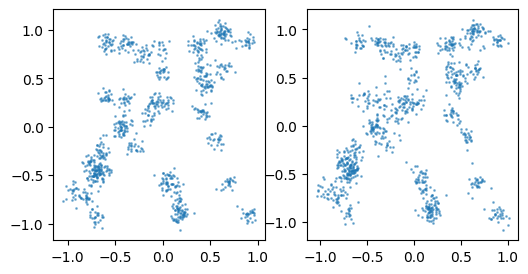

In [25]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
data = gmm.sample([1000]).to(device)
plt.scatter(data.cpu().detach()[:, 0], data.cpu().detach()[:, 1], alpha=0.5, s=1)
plt.subplot(1, 2, 2)
plt.scatter(samples.cpu().detach()[:, 0], samples.cpu().detach()[:, 1], alpha=0.5, s=1)